# 1-Import Libraries
Import required libraries for data processing, visualization, and machine learning.

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 2-Load Dataset
Load the diabetes dataset from CSV into a pandas DataFrame.

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 3-Preprocessing
Inspect data, handle missing values, and encode a categorical feature using get_dummies.

In [3]:
print('--- DATA INFO ---')
print(df.info())

print('\n--- STATISTICS ---')
print(df.describe())

# Convert medically invalid zeros to NaN.
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_invalid_cols:
    df[col] = df[col].replace(0, np.nan)

print('\n--- MISSING VALUES (BEFORE FILLING) ---')
print(df.isnull().sum())

# Fill missing values with median for numeric columns.
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print('\n--- MISSING VALUES (AFTER FILLING) ---')
print(df.isnull().sum())

# Build a categorical feature for encoding demonstration.
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[20, 30, 40, 50, 60, 100],
    labels=['20s', '30s', '40s', '50s', '60+'],
    include_lowest=True
)

print('\n--- CATEGORICAL FEATURE PREVIEW ---')
print(df[['Age', 'AgeGroup']].head())

df_encoded = pd.get_dummies(df, columns=['AgeGroup'], drop_first=False, dtype=int)
age_group_cols = [col for col in df_encoded.columns if col.startswith('AgeGroup_')]

print('\n--- ENCODING COMPLETED (get_dummies) ---')
print('Encoded columns:', age_group_cols)

--- DATA INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- STATISTICS ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.53

# 4-Visualization
Create and save histogram, scatter plot, and correlation heatmap.

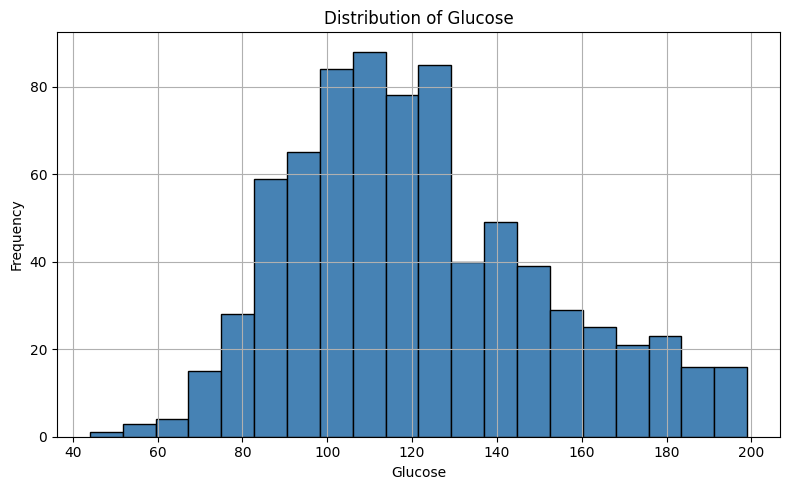

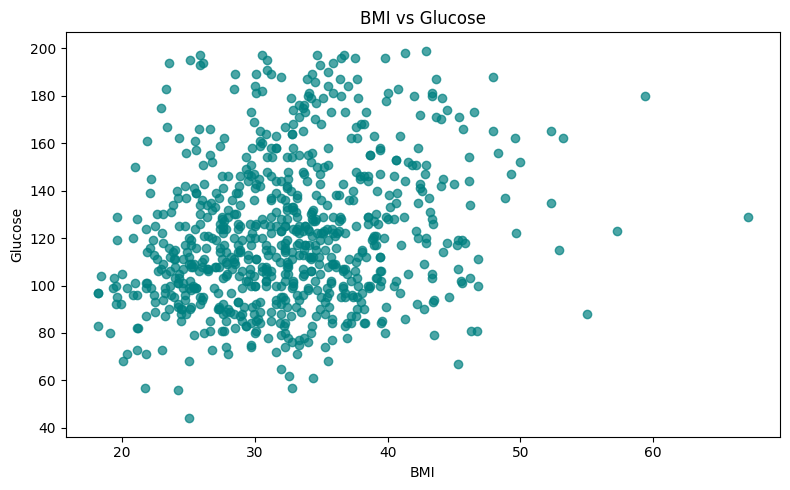

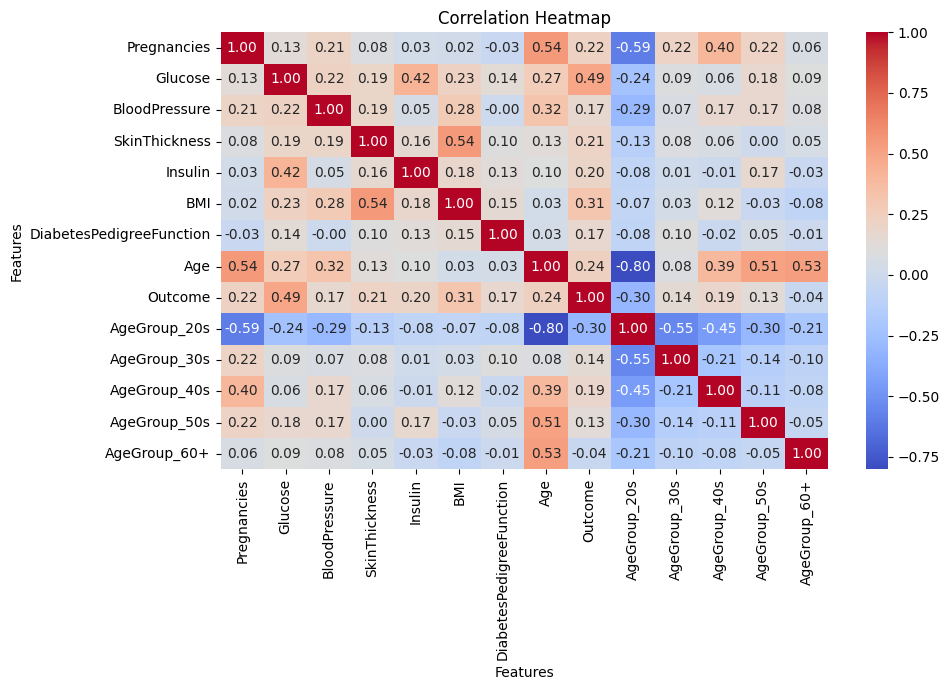

In [4]:
plt.figure(figsize=(8, 5))
df['Glucose'].hist(bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.title('Distribution of Glucose')
plt.tight_layout()
plt.savefig('plot_1_glucose_histogram.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['BMI'], df['Glucose'], alpha=0.7, color='teal')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.title('BMI vs Glucose')
plt.tight_layout()
plt.savefig('plot_2_bmi_vs_glucose_scatter.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.xlabel('Features')
plt.ylabel('Features')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot_3_correlation_heatmap.png', dpi=150)
plt.show()

# 5-Feature Selection
Select features and targets for classification and regression tasks.

In [5]:
clf_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'] + age_group_cols
reg_features = ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'] + age_group_cols

X_clf = df_encoded[clf_features]
y_clf = df_encoded['Outcome']

X_reg = df_encoded[reg_features]
y_reg = df_encoded['Glucose']

# 6-Train-Test Split
Split data into training and testing subsets, stratifying classification labels.

In [6]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# 7-Model Training
Train linear regression and controlled-depth decision tree models.

In [7]:
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

clf_model = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_model.fit(X_train_clf, y_train_clf)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

# 8-Evaluation
Evaluate both models with regression and classification metrics.

In [8]:
y_pred_reg = reg_model.predict(X_test_reg)
print('MSE:', mean_squared_error(y_test_reg, y_pred_reg))
print('R2:', r2_score(y_test_reg, y_pred_reg))

y_pred_clf = clf_model.predict(X_test_clf)
print('Accuracy:', accuracy_score(y_test_clf, y_pred_clf))
print('Confusion Matrix:\n', confusion_matrix(y_test_clf, y_pred_clf))
print('Classification Report:\n', classification_report(y_test_clf, y_pred_clf, target_names=['Non-Diabetic', 'Diabetic']))

MSE: 804.6642674640995
R2: 0.2003805235857824
Accuracy: 0.7467532467532467
Confusion Matrix:
 [[76 24]
 [15 39]]
Classification Report:
               precision    recall  f1-score   support

Non-Diabetic       0.84      0.76      0.80       100
    Diabetic       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



# 9-Prediction Demo
Run one hardcoded sample through both models.

In [9]:
sample_clf = pd.DataFrame(
    [[2, 140, 70, 30, 100, 32.0, 0.45, 35, 0, 1, 0, 0, 0]],
    columns=clf_features
)
sample_reg = pd.DataFrame(
    [[2, 70, 30, 100, 32.0, 0.45, 35, 0, 1, 0, 0, 0]],
    columns=reg_features
)

pred_glucose = reg_model.predict(sample_reg)[0]
pred_outcome = clf_model.predict(sample_clf)[0]

print('Predicted Glucose:', pred_glucose)
print('Diabetes Prediction:', 'Diabetic' if pred_outcome == 1 else 'Non-Diabetic')

Predicted Glucose: 119.0130012514528
Diabetes Prediction: Diabetic


# 10-User Input
Collect optional user input and show educational-purpose warning.

In [10]:
warnings.warn('This prediction demo is for educational purposes only and is not medical advice.', UserWarning)

try:
    preg = int(input('Enter Pregnancies: '))
    glucose = float(input('Enter Glucose: '))
    bp = float(input('Enter BloodPressure: '))
    skin = float(input('Enter SkinThickness: '))
    insulin = float(input('Enter Insulin: '))
    bmi = float(input('Enter BMI: '))
    dpf = float(input('Enter DiabetesPedigreeFunction: '))
    age = int(input('Enter Age: '))

    user_input_clf = pd.DataFrame(
        [[preg, glucose, bp, skin, insulin, bmi, dpf, age, 0, 0, 0, 0, 0]],
        columns=clf_features
    )
    user_input_reg = pd.DataFrame(
        [[preg, bp, skin, insulin, bmi, dpf, age, 0, 0, 0, 0, 0]],
        columns=reg_features
    )

    user_age_group = pd.cut(
        pd.Series([age]),
        bins=[20, 30, 40, 50, 60, 100],
        labels=['20s', '30s', '40s', '50s', '60+'],
        include_lowest=True
    ).iloc[0]

    if pd.notna(user_age_group):
        age_col = f'AgeGroup_{user_age_group}'
        if age_col in user_input_clf.columns:
            user_input_clf.loc[0, age_col] = 1
        if age_col in user_input_reg.columns:
            user_input_reg.loc[0, age_col] = 1

    user_glucose = reg_model.predict(user_input_reg)[0]
    user_outcome = clf_model.predict(user_input_clf)[0]

    print('Predicted Glucose:', user_glucose)
    print('Diabetes Prediction:', 'Diabetic' if user_outcome == 1 else 'Non-Diabetic')
except ValueError as e:
    print(f'Invalid numeric input ({e}). Skipping user prediction.')

C:\Users\dmunm\AppData\Local\Temp\ipykernel_36468\697179804.py:1: UserWarning: This prediction demo is for educational purposes only and is not medical advice.
  warnings.warn('This prediction demo is for educational purposes only and is not medical advice.', UserWarning)


Invalid numeric input (invalid literal for int() with base 10: ''). Skipping user prediction.
